# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

Датасет: Hotel Booking Demand
Источник: Kaggle (https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

Числовые пропуски: children (количество детей)

Категориальные пропуски: country (страна), agent (агент), company (компания)

In [15]:
# @title 1. Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from google.colab import files

from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

%matplotlib inline
sns.set(style="ticks")

In [16]:
# @title 2. Загрузка ZIP-архива с датасетом
print("Загрузите ZIP-архив с датасетом Hotel Booking Demand")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
print(f"Загружен файл: {zip_filename}")

extract_path = 'dataset'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Файлы в архиве:")
    for file in zip_ref.namelist():
        print(f"  - {file}")

# Загружаем CSV файл
csv_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

if len(csv_files) > 0:
    df = pd.read_csv(csv_files[0])
    print(f"\nЗагружен датасет: {os.path.basename(csv_files[0])}")
else:
    print("CSV файлы не найдены")

Загрузите ZIP-архив с датасетом Hotel Booking Demand


Saving archive (1).zip to archive (1) (1).zip
Загружен файл: archive (1) (1).zip
Файлы в архиве:
  - hotel_bookings.csv

Загружен датасет: hotel_bookings.csv


In [40]:
# @title 3. Первичный анализ данных
print("ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print(f"Размер набора данных: {df.shape}")

print("\nТипы колонок:")
print(df.dtypes)

print("\nКоличество пропущенных значений:")
print(df.isnull().sum())

print("\nПервые 5 строк датасета:")
display(df.head())

total_count = df.shape[0]
print(f"\nВсего строк: {total_count}")

ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
Размер набора данных: (119390, 32)

Типы колонок:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
de

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



Всего строк: 119390


In [41]:
# @title 4. Выявление числовых колонок с пропусками
print("ЧИСЛОВЫЕ КОЛОНКИ С ПРОПУЩЕННЫМИ ЗНАЧЕНИЯМИ")

num_cols = []
for col in df.columns:
    temp_null_count = df[df[col].isnull()].shape[0]
    dt = str(df[col].dtype)
    if temp_null_count > 0 and (dt == 'float64' or dt == 'int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print(f"Колонка {col}. Тип данных {dt}. Количество пустых значений {temp_null_count}, {temp_perc}%.")

print(f"\nЧисловые колонки с пропусками: {num_cols}")

ЧИСЛОВЫЕ КОЛОНКИ С ПРОПУЩЕННЫМИ ЗНАЧЕНИЯМИ
Колонка children. Тип данных float64. Количество пустых значений 4, 0.0%.
Колонка agent. Тип данных float64. Количество пустых значений 16340, 13.69%.
Колонка company. Тип данных float64. Количество пустых значений 112593, 94.31%.

Числовые колонки с пропусками: ['children', 'agent', 'company']


Размер data_num: (119390, 3)


,children,agent,company
0,0.0,NaN,NaN
1,0.0,NaN,NaN
2,0.0,NaN,NaN
3,0.0,304.0,NaN
4,0.0,240.0,NaN



Гистограммы по признакам:


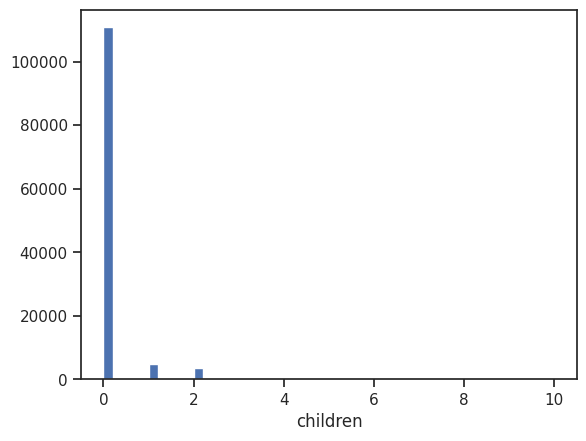

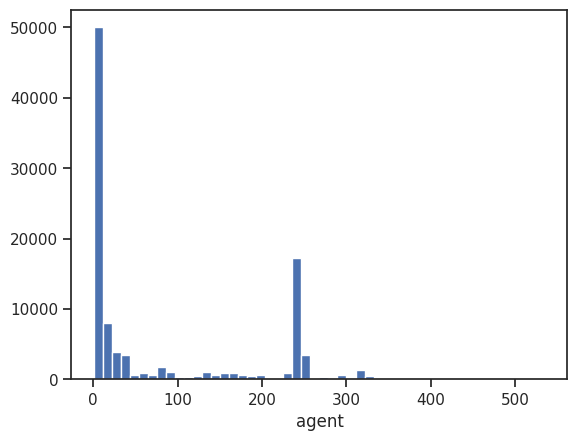

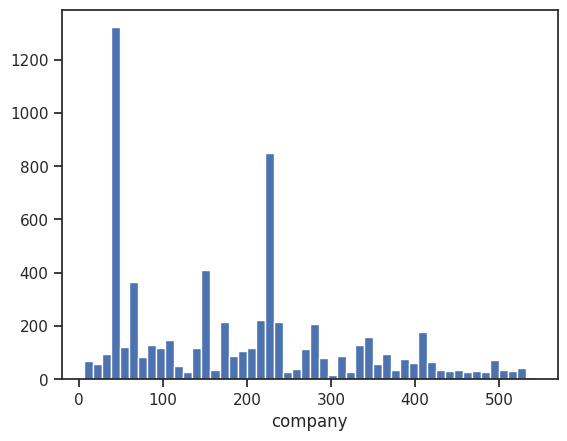

In [42]:
# @title 5. Визуализация числовых признаков с пропусками
data_num = df[num_cols]
print(f"Размер data_num: {data_num.shape}")
display(data_num.head())

print("\nГистограммы по признакам:")
for col in data_num:
    plt.hist(df[col].dropna(), 50)
    plt.xlabel(col)
    plt.show()

Гистограммы показывают:
- Форму распределения данных
- Наличие выбросов
- Центральную тенденцию
- Разброс значений
Для children большинство значений 0, для agent и company - множество уникальных значений.

In [43]:
# @title 6. Тестирование стратегий заполнения пропусков

strategies = ['mean', 'median', 'most_frequent']

def test_num_impute_col(dataset, column, strategy_param):
  temp_data = dataset[[column]]

  indicator = MissingIndicator()
  mask_missing_values_only = indicator.fit_transform(temp_data)

  imp_num = SimpleImputer(strategy=strategy_param)
  data_num_imp = imp_num.fit_transform(temp_data)

  filled_data = data_num_imp[mask_missing_values_only]

  return column, strategy_param, filled_data.size, filled_data[0] if filled_data.size > 0 else None

for col in num_cols:
  print(f"\nКолонка: {col}")
  print(df[[col]].describe())

  for strategy in strategies:
      result = test_num_impute_col(df, col, strategy)
      print(f"Стратегия {strategy}: заполнено {result[2]} значений, первое={result[3]}")


Колонка: children
            children
count  119386.000000
mean        0.103890
std         0.398561
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        10.000000
Стратегия mean: заполнено 4 значений, первое=0.10388990333874994
Стратегия median: заполнено 4 значений, первое=0.0
Стратегия most_frequent: заполнено 4 значений, первое=0.0

Колонка: agent
               agent
count  103050.000000
mean       86.693382
std       110.774548
min         1.000000
25%         9.000000
50%        14.000000
75%       229.000000
max       535.000000
Стратегия mean: заполнено 16340 значений, первое=86.69338185346919
Стратегия median: заполнено 16340 значений, первое=14.0
Стратегия most_frequent: заполнено 16340 значений, первое=9.0

Колонка: company
           company
count  6797.000000
mean    189.266735
std     131.655015
min       6.000000
25%      62.000000
50%     179.000000
75%     270.000000
max     543.000000
Стратегия mean: заполнено 112593 значен

- mean: заполнение средним арифметическим
- median: заполнение медианой
- most_frequent: заполнение самым частым значением

In [44]:
# @title 7. Заполнение пропусков в числовых данных
df_clean = df.copy()

for col in num_cols:
    # Для children используем медиану (0.0) - т.к. большинство броней без детей
    if col == 'children':
        imp_num = SimpleImputer(strategy='median')
        strategy_used = 'медианой'
    # Для agent используем среднее
    elif col == 'agent':
        imp_num = SimpleImputer(strategy='mean')
        strategy_used = 'средним'
    # Для company используем константу 0 (нет компании)
    else:
        imp_num = SimpleImputer(strategy='constant', fill_value=0)
        strategy_used = 'константой 0'

    df_clean[[col]] = imp_num.fit_transform(df_clean[[col]])
    print(f"{col}: заполнено {strategy_used}")

print("\nПроверка после заполнения:")
print(df_clean[num_cols].isnull().sum())

children: заполнено медианой
agent: заполнено средним
company: заполнено константой 0

Проверка после заполнения:
children    0
agent       0
company     0
dtype: int64


- children: медиана (0) - т.к. распределение смещено к 0
- agent: среднее - для сохранения среднего значения
- company: константа 0 - т.к. 94% пропусков

In [45]:
# @title 8. Выявление категориальных колонок с пропусками
cat_cols = []
for col in df.columns:
    temp_null_count = df[df[col].isnull()].shape[0]
    dt = str(df[col].dtype)
    if temp_null_count > 0 and dt == 'object':
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print(f"Колонка {col}. Тип данных {dt}. Количество пустых значений {temp_null_count}, {temp_perc}%.")

print(f"\nКатегориальные колонки с пропусками: {cat_cols}")

Колонка country. Тип данных object. Количество пустых значений 488, 0.41%.

Категориальные колонки с пропусками: ['country']


In [46]:
# @title 9. Заполнение пропусков в категориальных данных
if len(cat_cols) > 0:
    for col in cat_cols:
        temp_data = df[[col]]
        print(f"\nКолонка: {col}")
        print(f"Пропусков: {temp_data[col].isnull().sum()}")

        # Импьютация наиболее частыми значениями
        imp_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        data_imp_freq = imp_freq.fit_transform(temp_data)
        mode_value = imp_freq.statistics_[0]
        print(f"Мода (самое частое значение): {mode_value}")
        print(f"После заполнения модой - первые 10 уникальных значений (отсортированы):")
        print(np.unique(data_imp_freq)[:10])

        # Импьютация константой
        imp_const = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='UNKNOWN')
        data_imp_const = imp_const.fit_transform(temp_data)
        print(f"После заполнения константой 'UNKNOWN' - первые 10 уникальных значений:")
        print(np.unique(data_imp_const)[:10])

    print("\nПрименение импьютации к данным:")
    for col in cat_cols:
        # Для страны используем самую частую страну
        imp_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        mode_before = imp_freq.fit(df_clean[[col]]).statistics_[0]
        df_clean[col] = imp_freq.fit_transform(df_clean[[col]]).ravel()
        print(f"{col}: заполнено модой '{mode_before}'")


Колонка: country
Пропусков: 488
Мода (самое частое значение): PRT
После заполнения модой - первые 10 уникальных значений (отсортированы):
['ABW' 'AGO' 'AIA' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ASM' 'ATA']
После заполнения константой 'UNKNOWN' - первые 10 уникальных значений:
['ABW' 'AGO' 'AIA' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ASM' 'ATA']

Применение импьютации к данным:
country: заполнено модой 'PRT'


Все 488 пропусков в колонке country заполнены значением 'PRT' (Португалия), что является самым частым значением в датасете и сохраняет реальное распределение данных.

Логично с точки зрения бизнеса - отели в Португалии чаще всего бронируют португальцы

Статистически обосновано - мода сохраняет распределение данных

Малое количество пропусков - 0.4% не исказит статистику


Всего категориальных колонок в датасете: 12
Категориальные колонки: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
0,Resort Hotel,July,BB,PRT,Direct,Direct,C,C,No Deposit,Transient,Check-Out,2015-07-01
1,Resort Hotel,July,BB,PRT,Direct,Direct,C,C,No Deposit,Transient,Check-Out,2015-07-01
2,Resort Hotel,July,BB,GBR,Direct,Direct,A,C,No Deposit,Transient,Check-Out,2015-07-02
3,Resort Hotel,July,BB,GBR,Corporate,Corporate,A,A,No Deposit,Transient,Check-Out,2015-07-02
4,Resort Hotel,July,BB,GBR,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-07-03


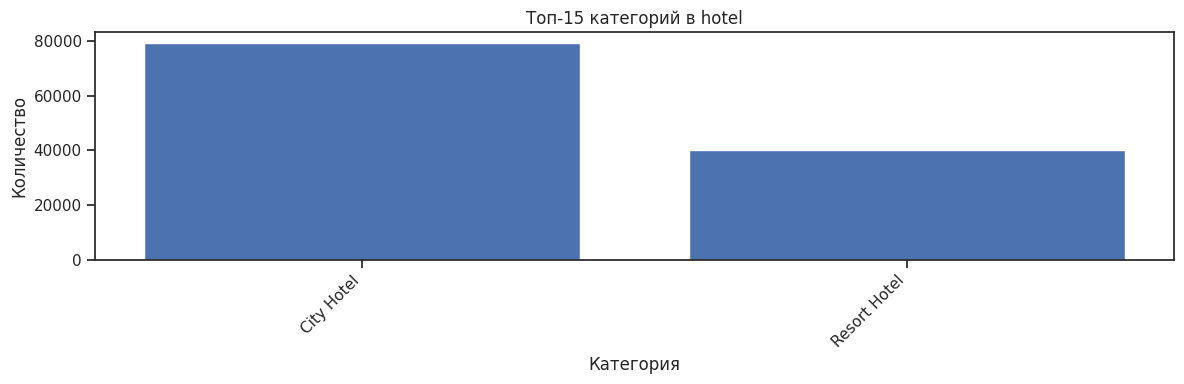

Колонка: hotel
Всего уникальных значений: 2
Топ-3 категории: ['City Hotel', 'Resort Hotel']
--------------------------------------------------


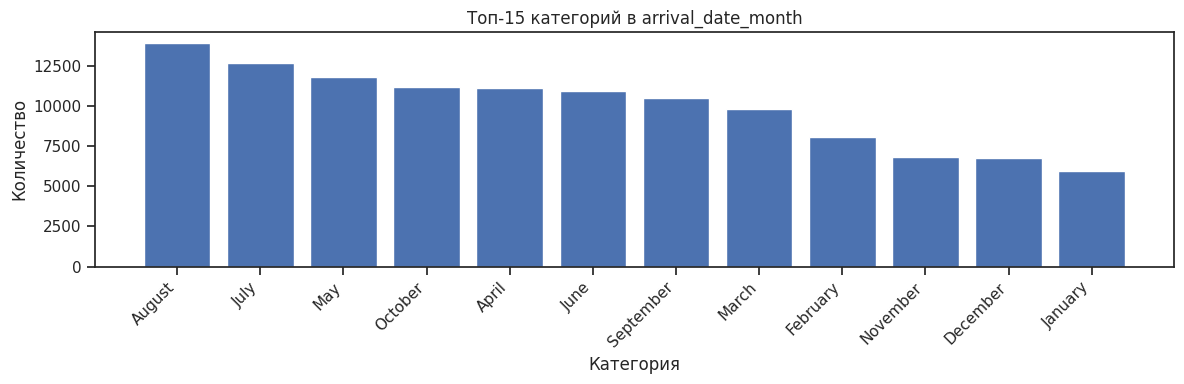

Колонка: arrival_date_month
Всего уникальных значений: 12
Топ-3 категории: ['August', 'July', 'May']
--------------------------------------------------


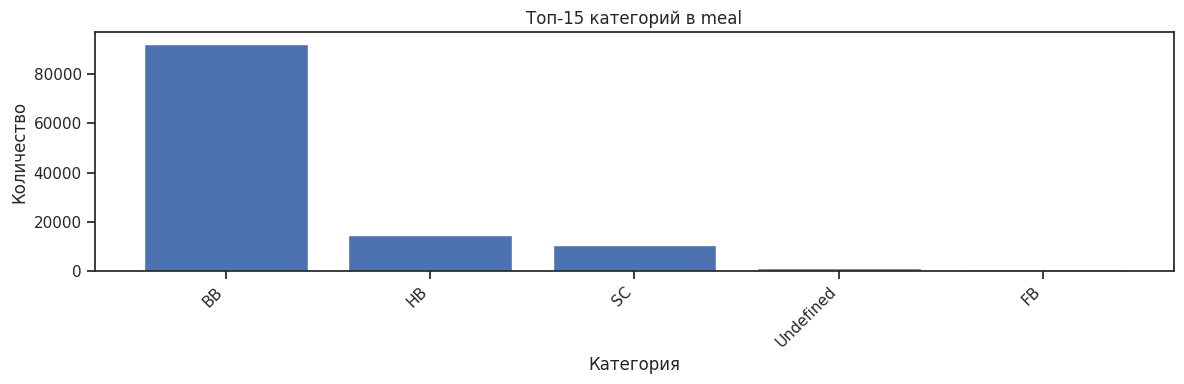

Колонка: meal
Всего уникальных значений: 5
Топ-3 категории: ['BB', 'HB', 'SC']
--------------------------------------------------


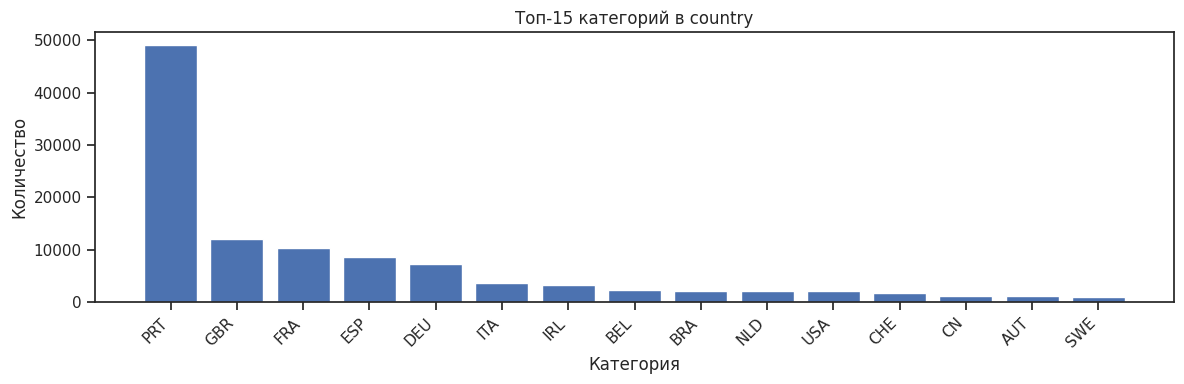

Колонка: country
Всего уникальных значений: 177
Топ-3 категории: ['PRT', 'GBR', 'FRA']
--------------------------------------------------


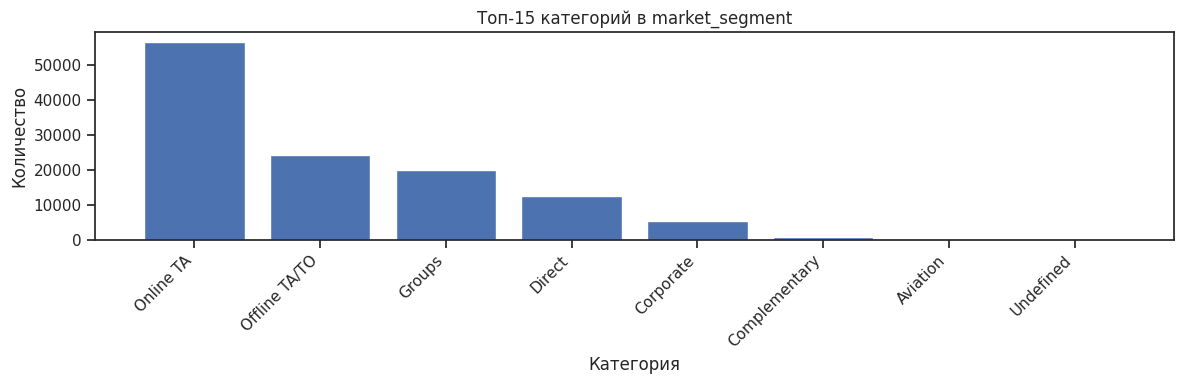

Колонка: market_segment
Всего уникальных значений: 8
Топ-3 категории: ['Online TA', 'Offline TA/TO', 'Groups']
--------------------------------------------------


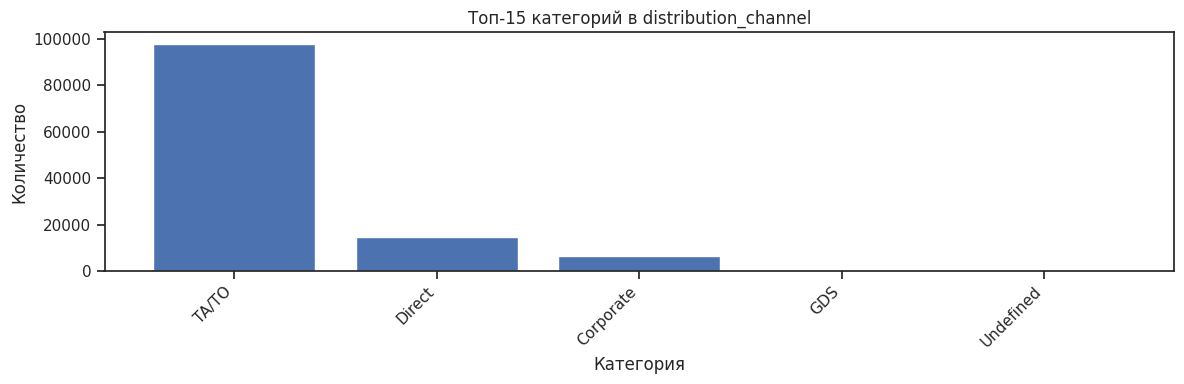

Колонка: distribution_channel
Всего уникальных значений: 5
Топ-3 категории: ['TA/TO', 'Direct', 'Corporate']
--------------------------------------------------


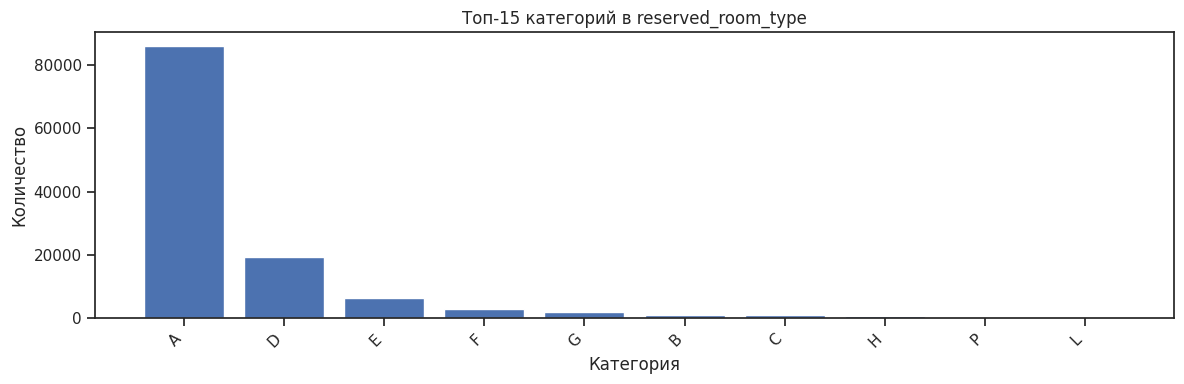

Колонка: reserved_room_type
Всего уникальных значений: 10
Топ-3 категории: ['A', 'D', 'E']
--------------------------------------------------


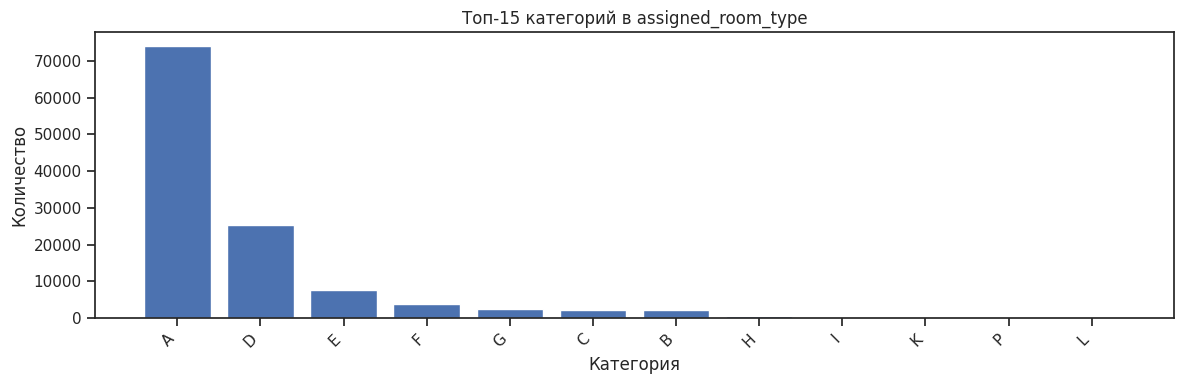

Колонка: assigned_room_type
Всего уникальных значений: 12
Топ-3 категории: ['A', 'D', 'E']
--------------------------------------------------


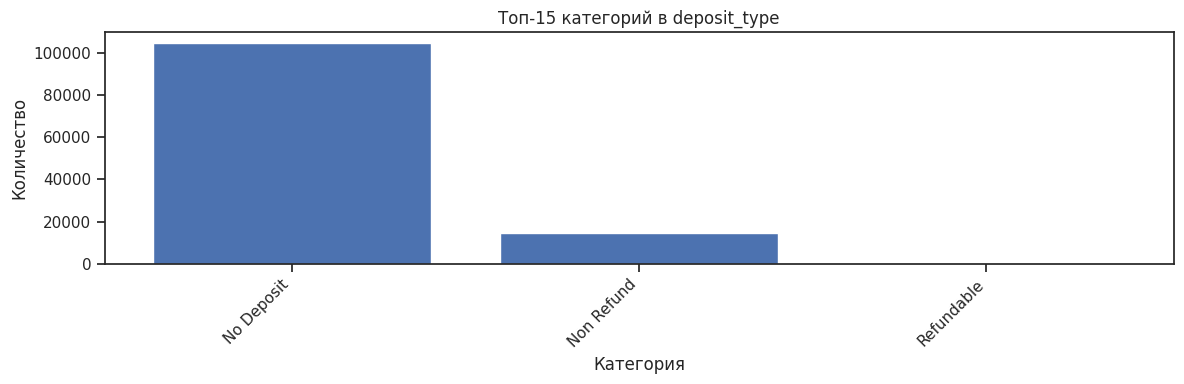

Колонка: deposit_type
Всего уникальных значений: 3
Топ-3 категории: ['No Deposit', 'Non Refund', 'Refundable']
--------------------------------------------------


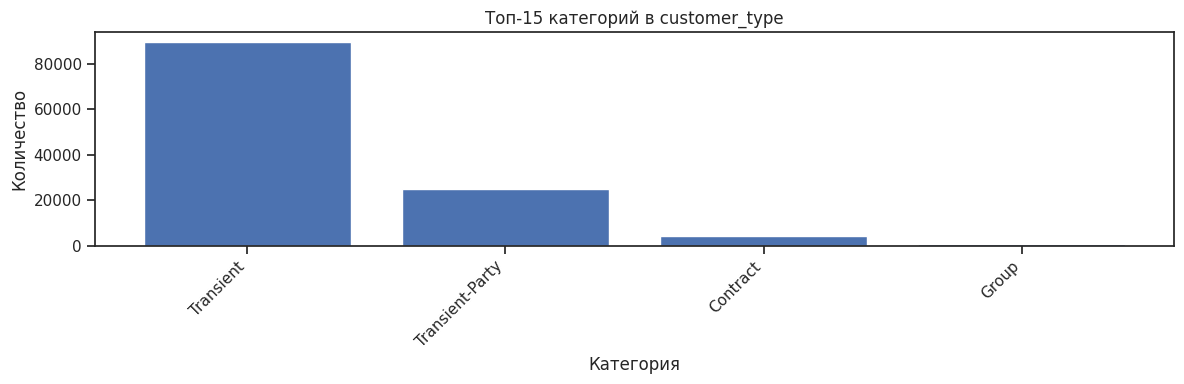

Колонка: customer_type
Всего уникальных значений: 4
Топ-3 категории: ['Transient', 'Transient-Party', 'Contract']
--------------------------------------------------


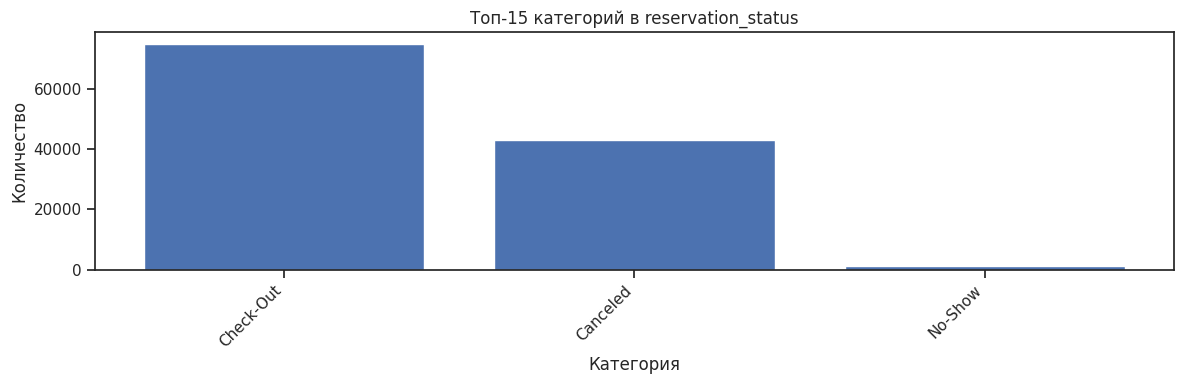

Колонка: reservation_status
Всего уникальных значений: 3
Топ-3 категории: ['Check-Out', 'Canceled', 'No-Show']
--------------------------------------------------


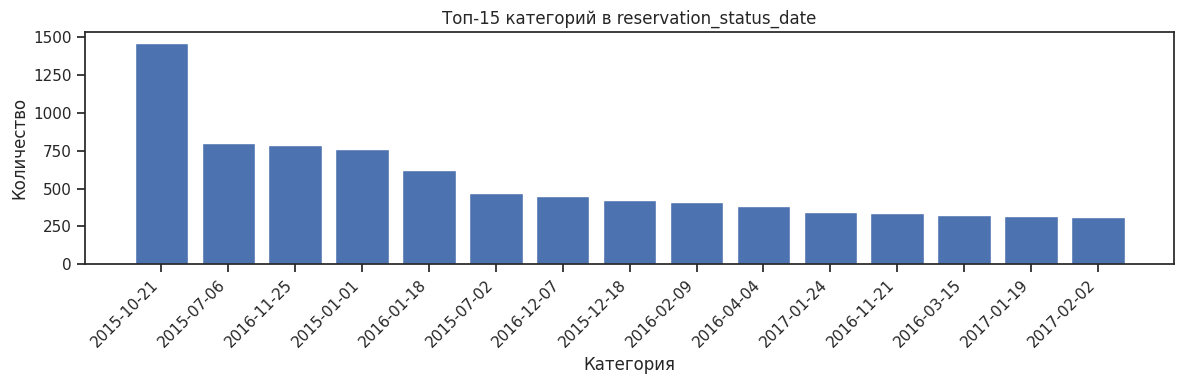

Колонка: reservation_status_date
Всего уникальных значений: 926
Топ-3 категории: ['2015-10-21', '2015-07-06', '2016-11-25']
--------------------------------------------------


In [47]:
# @title 10. Подготовка всех категориальных данных для кодирования
# Получаем категориальные колонки
all_cat_cols = []
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        all_cat_cols.append(col)

print(f"Всего категориальных колонок в датасете: {len(all_cat_cols)}")
print(f"Категориальные колонки: {all_cat_cols}")

if len(all_cat_cols) > 0:
    cat_enc = df_clean[all_cat_cols].copy()
    display(cat_enc.head())
    for col in all_cat_cols:
        plt.figure(figsize=(12, 4))
        value_counts = cat_enc[col].value_counts().head(15)
        plt.bar(range(len(value_counts)), value_counts.values)
        plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
        plt.title(f'Топ-15 категорий в {col}')
        plt.xlabel('Категория')
        plt.ylabel('Количество')
        plt.tight_layout()
        plt.show()
        print(f"Колонка: {col}")
        print(f"Всего уникальных значений: {cat_enc[col].nunique()}")
        print(f"Топ-3 категории: {list(value_counts.index[:3])}")
        print("-" * 50)
else:
    print("Категориальных колонок не найдено")

In [48]:
# @title 11. Label Encoding для всех категориальных признаков
if len(all_cat_cols) > 0:
    from sklearn.preprocessing import LabelEncoder

    for col in all_cat_cols:
        print(f"\nКолонка: {col}")
        print(f"Уникальные значения до: {df_clean[col].unique()[:5]}")

        le = LabelEncoder()
        df_clean[f"{col}_le"] = le.fit_transform(df_clean[col].astype(str))

        print(f"Классы (classes_): {le.classes_[:5]}")
        print(f"Уникальные значения после: {np.unique(df_clean[f'{col}_le'])[:5]}")


Колонка: hotel
Уникальные значения до: ['Resort Hotel' 'City Hotel']
Классы (classes_): ['City Hotel' 'Resort Hotel']
Уникальные значения после: [0 1]

Колонка: arrival_date_month
Уникальные значения до: ['July' 'August' 'September' 'October' 'November']
Классы (classes_): ['April' 'August' 'December' 'February' 'January']
Уникальные значения после: [0 1 2 3 4]

Колонка: meal
Уникальные значения до: ['BB' 'FB' 'HB' 'SC' 'Undefined']
Классы (classes_): ['BB' 'FB' 'HB' 'SC' 'Undefined']
Уникальные значения после: [0 1 2 3 4]

Колонка: country
Уникальные значения до: ['PRT' 'GBR' 'USA' 'ESP' 'IRL']
Классы (classes_): ['ABW' 'AGO' 'AIA' 'ALB' 'AND']
Уникальные значения после: [0 1 2 3 4]

Колонка: market_segment
Уникальные значения до: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary']
Классы (classes_): ['Aviation' 'Complementary' 'Corporate' 'Direct' 'Groups']
Уникальные значения после: [0 1 2 3 4]

Колонка: distribution_channel
Уникальные значения до: ['Direct' 'Corpora

Демонстрация one-hot для колонок: ['hotel', 'arrival_date_month', 'meal']

Колонка: hotel
Форма исходная: (119390, 1)
Форма после one-hot: (119390, 2)
Категории: [array(['City Hotel', 'Resort Hotel'], dtype=object)]
Первые 5 строк one-hot представления:
[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


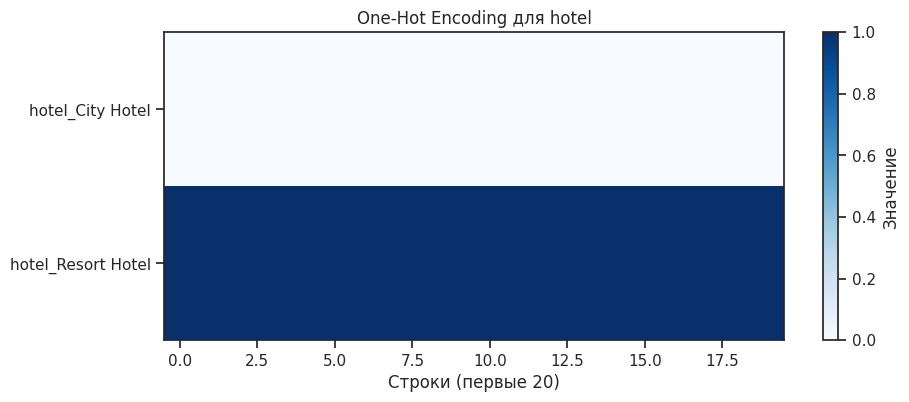

Добавлено 2 новых признаков

Колонка: arrival_date_month
Форма исходная: (119390, 1)
Форма после one-hot: (119390, 12)
Категории: [array(['April', 'August', 'December', 'February', 'January', 'July',
       'June', 'March', 'May', 'November', 'October', 'September'],
      dtype=object)]
Первые 5 строк one-hot представления:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Добавлено 12 новых признаков

Колонка: meal
Форма исходная: (119390, 1)
Форма после one-hot: (119390, 5)
Категории: [array(['BB', 'FB', 'HB', 'SC', 'Undefined'], dtype=object)]
Первые 5 строк one-hot представления:
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


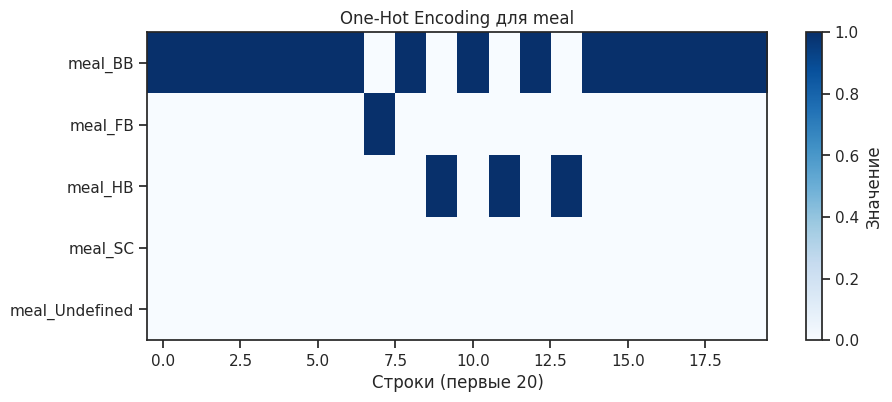

Добавлено 5 новых признаков


In [49]:
# @title 12. One-Hot Encoding для категориальных признаков
if len(all_cat_cols) > 0:
    from sklearn.preprocessing import OneHotEncoder

    # возьмем первые 3 категориальных признака
    demo_cols = all_cat_cols[:3]
    print(f"Демонстрация one-hot для колонок: {demo_cols}")

    for col in demo_cols:
        print(f"\nКолонка: {col}")
        temp_data = df_clean[[col]]

        ohe = OneHotEncoder(sparse_output=False)
        encoded_data = ohe.fit_transform(temp_data)

        print(f"Форма исходная: {temp_data.shape}")
        print(f"Форма после one-hot: {encoded_data.shape}")
        print(f"Категории: {ohe.categories_}")
        print(f"Первые 5 строк one-hot представления:")
        print(encoded_data[:5])

        # Визуализация one-hot результатов
        if encoded_data.shape[1] <= 10:  # Только если не слишком много категорий
            plt.figure(figsize=(10, 4))
            plt.imshow(encoded_data[:20].T, aspect='auto', cmap='Blues')
            plt.yticks(range(encoded_data.shape[1]), [f"{col}_{cat}" for cat in ohe.categories_[0]])
            plt.xlabel('Строки (первые 20)')
            plt.title(f'One-Hot Encoding для {col}')
            plt.colorbar(label='Значение')
            plt.show()

        # Добавляем в датасет
        encoded_df = pd.DataFrame(
            encoded_data,
            columns=[f"{col}_{cat}" for cat in ohe.categories_[0]]
        )
        df_clean = pd.concat([df_clean, encoded_df], axis=1)
        print(f"Добавлено {encoded_data.shape[1]} новых признаков")

1. Колонка: hotel

Создано 2 бинарные колонки: hotel_City Hotel и hotel_Resort Hotel

Первые 5 строк показывают [0. 1.] - это означает:
hotel_City Hotel = 0 (нет)
hotel_Resort Hotel = 1 (да)

Следовательно, первые 5 записей - это Resort Hotel

2. Колонка: arrival_date_month

Создано 12 бинарных колонок (по одной на каждый месяц)

Первые 5 строк показывают 1 на 6-й позиции (индекс 5)

Это соответствует категории 'July' (июль)

Все 5 первых записей были сделаны в июле

3. Колонка: meal

Создано 5 бинарных колонок:

meal_BB (Bed & Breakfast)

meal_FB (Full Board)

meal_HB (Half Board)

meal_SC (Self Catering)

meal_Undefined

Первые 5 строк показывают [1. 0. 0. 0. 0.] - это BB (Bed & Breakfast)

Все первые 5 записей выбрали только завтрак

Оригинальных категориальных колонок: 12
Создано one-hot колонок: 1167

Первые 5 строк результата:


,hotel_City Hotel,hotel_Resort Hotel,arrival_date_month_April,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,...,reservation_status_date_2017-09-03,reservation_status_date_2017-09-04,reservation_status_date_2017-09-05,reservation_status_date_2017-09-06,reservation_status_date_2017-09-07,reservation_status_date_2017-09-08,reservation_status_date_2017-09-09,reservation_status_date_2017-09-10,reservation_status_date_2017-09-12,reservation_status_date_2017-09-14
0,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


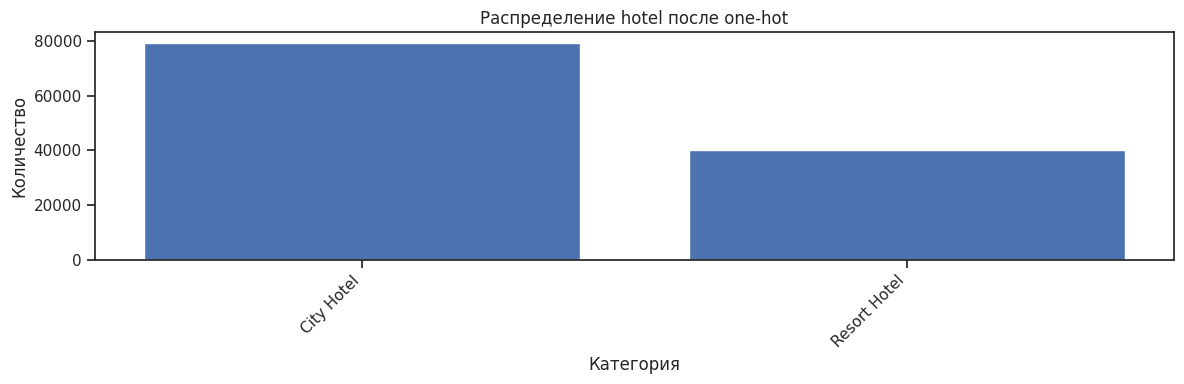

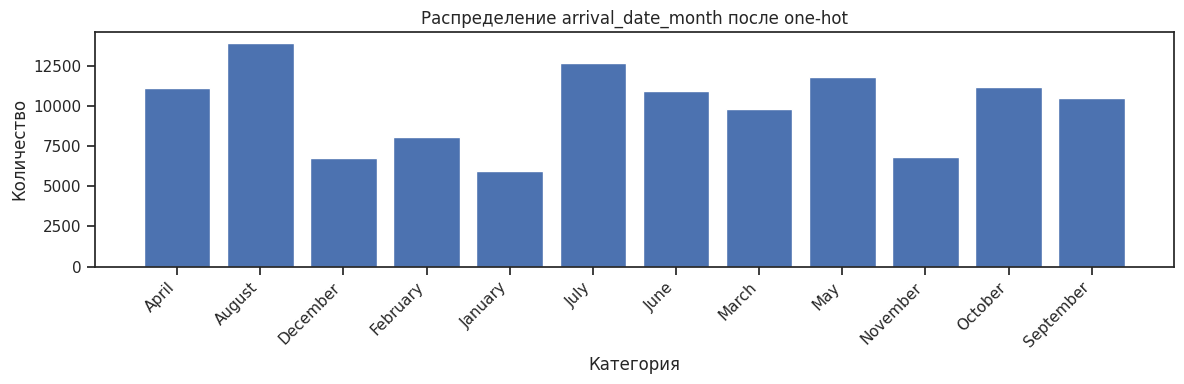

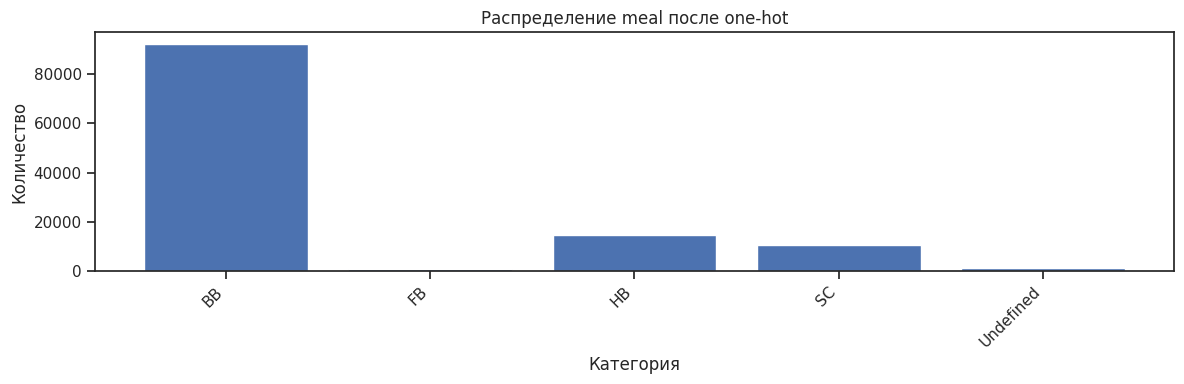

(Демонстрация - новые признаки не добавлены, чтобы избежать дублирования)


In [50]:
# @title 13. Быстрое one-hot кодирование с pandas get_dummies
if len(all_cat_cols) > 0:
    # Применяем get_dummies ко всем категориальным колонкам
    dummies = pd.get_dummies(df_clean[all_cat_cols], dummy_na=False)

    print(f"Оригинальных категориальных колонок: {len(all_cat_cols)}")
    print(f"Создано one-hot колонок: {dummies.shape[1]}")
    print(f"\nПервые 5 строк результата:")
    display(dummies.head())

    # Визуализация для нескольких колонок
    for col in all_cat_cols[:3]:
        plt.figure(figsize=(12, 4))
        # Получаем все one-hot колонки для данного признака
        pattern = f"^{col}_"
        col_dummies = [c for c in dummies.columns if c.startswith(f"{col}_")]

        if len(col_dummies) > 0 and len(col_dummies) <= 20:
            sums = dummies[col_dummies].sum()
            plt.bar(range(len(sums)), sums.values)
            plt.xticks(range(len(sums)), [c.replace(f"{col}_", "") for c in sums.index], rotation=45, ha='right')
            plt.title(f'Распределение {col} после one-hot')
            plt.xlabel('Категория')
            plt.ylabel('Количество')
            plt.tight_layout()
            plt.show()

    # Добавляем в датасет
    #df_clean = pd.concat([df_clean, dummies], axis=1)
    print("(Демонстрация - новые признаки не добавлены, чтобы избежать дублирования)")


Колонка: lead_time
До масштабирования - мин: 0.00, макс: 737.00
После масштабирования - мин: 0.00, макс: 1.00


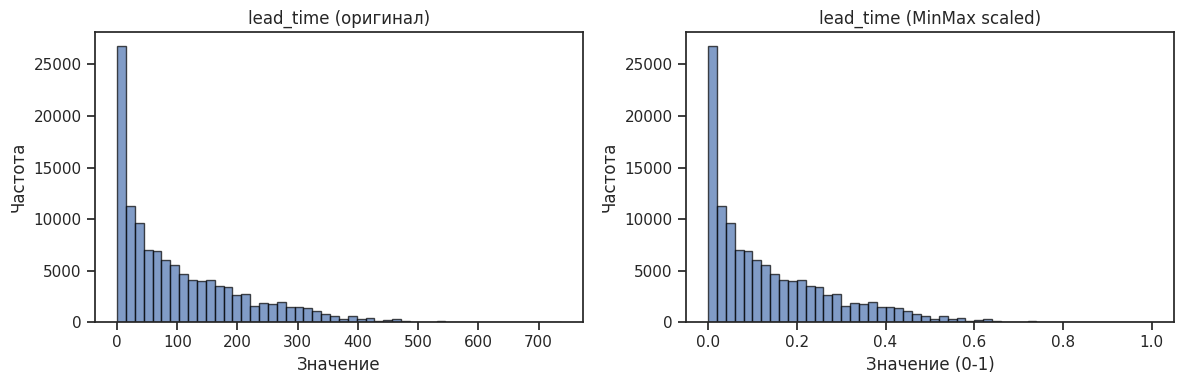

Сравнение распределений: слева - оригинальные значения в масштабе 0-737, справа - после MinMax все значения в диапазоне [0,1].

Колонка: stays_in_weekend_nights
До масштабирования - мин: 0.00, макс: 19.00
После масштабирования - мин: 0.00, макс: 1.00


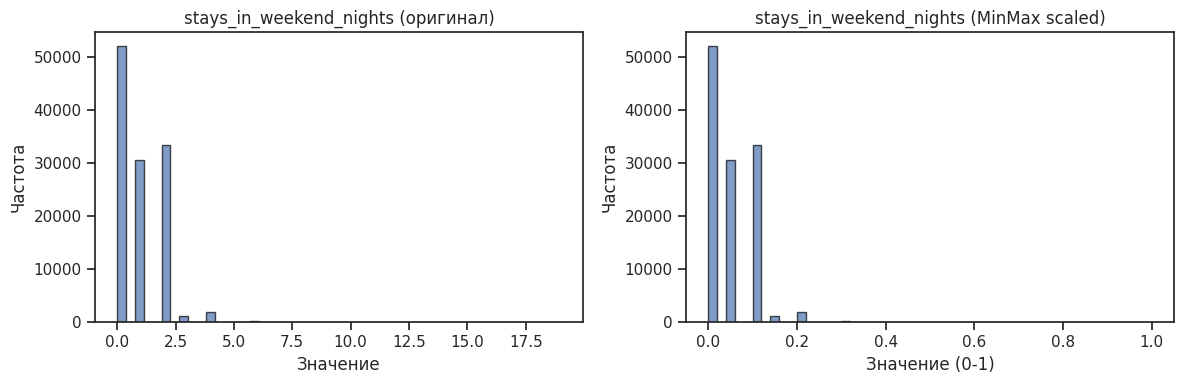

Сравнение распределений: слева - оригинальные значения в масштабе 0-19, справа - после MinMax все значения в диапазоне [0,1].

Колонка: stays_in_week_nights
До масштабирования - мин: 0.00, макс: 50.00
После масштабирования - мин: 0.00, макс: 1.00


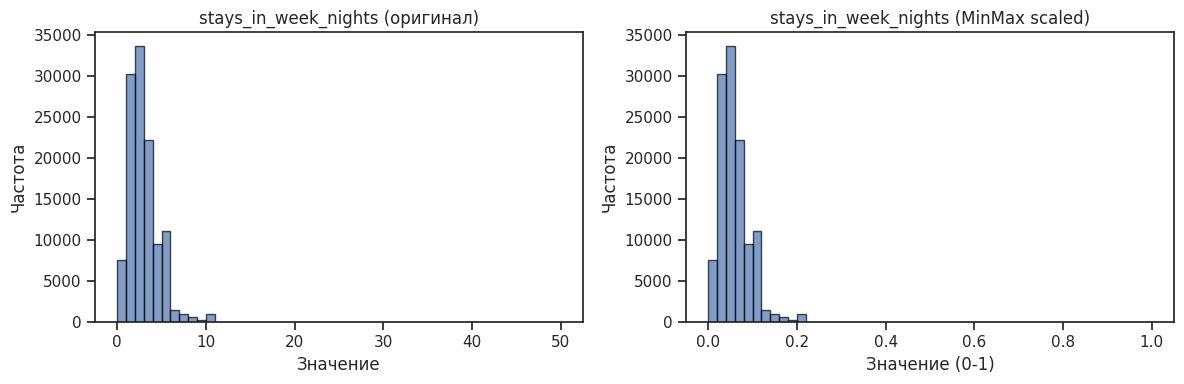

Сравнение распределений: слева - оригинальные значения в масштабе 0-50, справа - после MinMax все значения в диапазоне [0,1].

Колонка: adults
До масштабирования - мин: 0.00, макс: 55.00
После масштабирования - мин: 0.00, макс: 1.00


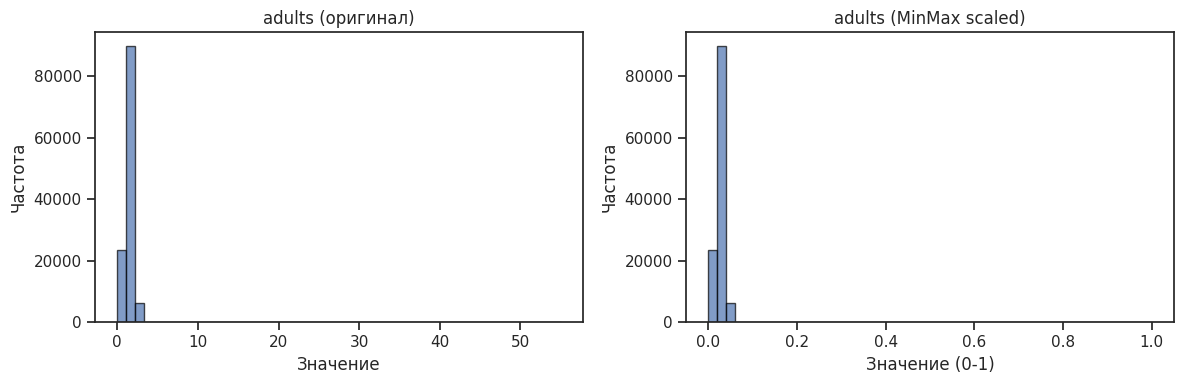

Сравнение распределений: слева - оригинальные значения в масштабе 0-55, справа - после MinMax все значения в диапазоне [0,1].

Колонка: children
До масштабирования - мин: 0.00, макс: 10.00
После масштабирования - мин: 0.00, макс: 1.00


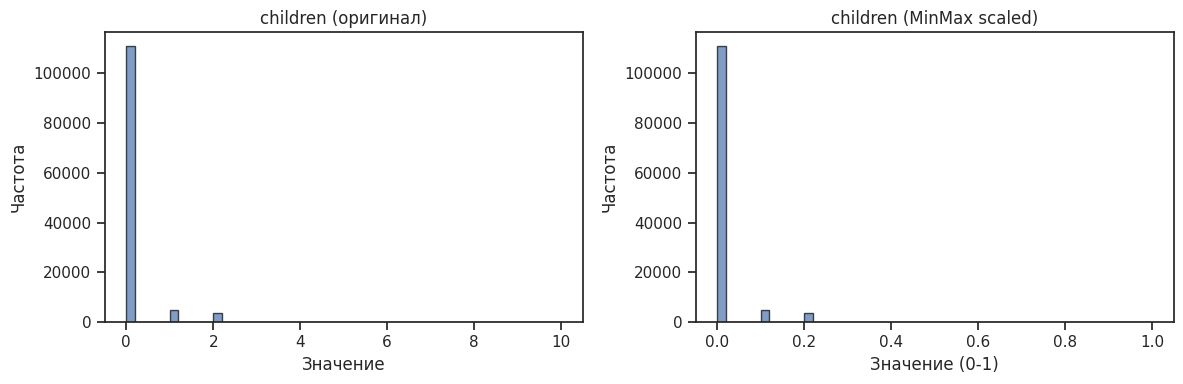

Сравнение распределений: слева - оригинальные значения в масштабе 0-10, справа - после MinMax все значения в диапазоне [0,1].

Колонка: babies
До масштабирования - мин: 0.00, макс: 10.00
После масштабирования - мин: 0.00, макс: 1.00


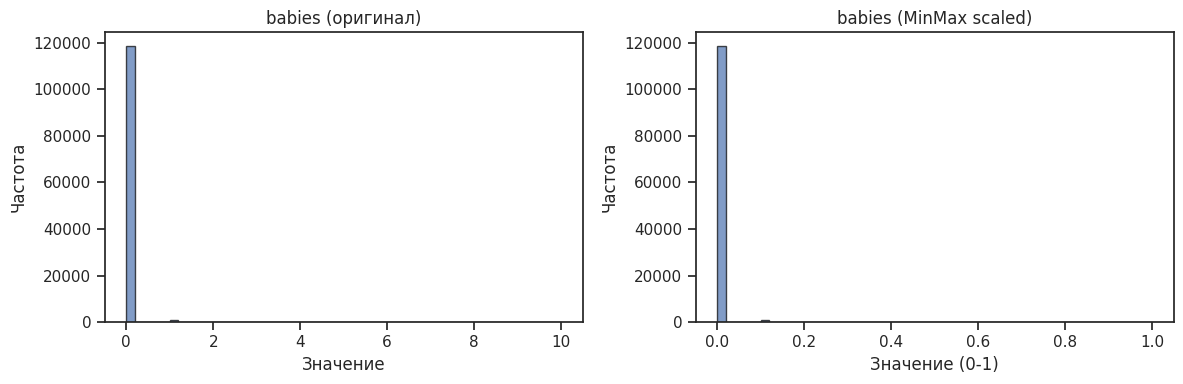

Сравнение распределений: слева - оригинальные значения в масштабе 0-10, справа - после MinMax все значения в диапазоне [0,1].

Колонка: adr
До масштабирования - мин: -6.38, макс: 5400.00
После масштабирования - мин: 0.00, макс: 1.00


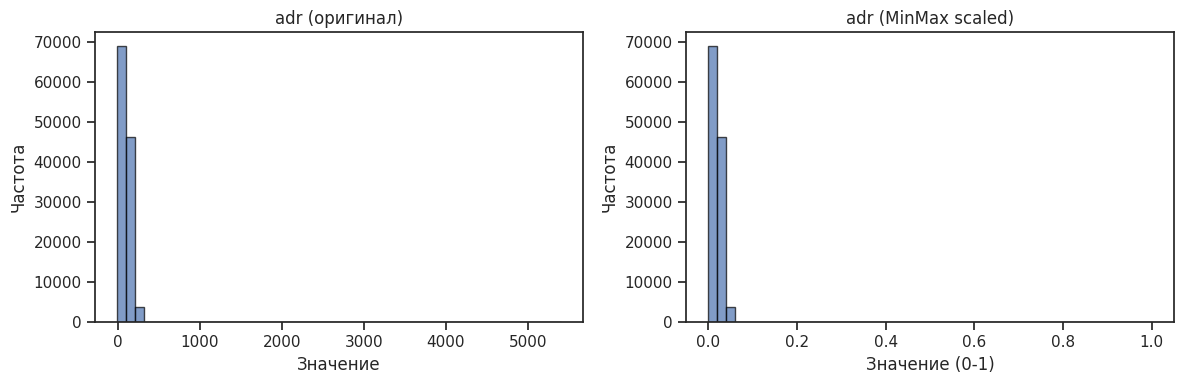

Сравнение распределений: слева - оригинальные значения в масштабе -6-5400, справа - после MinMax все значения в диапазоне [0,1].


In [51]:
# @title 14. MinMax масштабирование числовых признаков
# Выберем числовые признаки для масштабирования
numeric_features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                    'adults', 'children', 'babies', 'adr']
from sklearn.preprocessing import MinMaxScaler

for col in numeric_features:
    if col in df_clean.columns:
        print(f"\nКолонка: {col}")
        print(f"До масштабирования - мин: {df_clean[col].min():.2f}, макс: {df_clean[col].max():.2f}")

        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(df_clean[[col]])

        print(f"После масштабирования - мин: {scaled_data.min():.2f}, макс: {scaled_data.max():.2f}")

        df_clean[f"{col}_minmax"] = scaled_data

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.hist(df_clean[col], 50, edgecolor='black', alpha=0.7)
        plt.title(f"{col} (оригинал)")
        plt.xlabel('Значение')
        plt.ylabel('Частота')

        plt.subplot(1, 2, 2)
        plt.hist(scaled_data, 50, edgecolor='black', alpha=0.7)
        plt.title(f"{col} (MinMax scaled)")
        plt.xlabel('Значение (0-1)')
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.show()
        print(f"Сравнение распределений: слева - оригинальные значения в масштабе {df_clean[col].min():.0f}-{df_clean[col].max():.0f}, справа - после MinMax все значения в диапазоне [0,1].")

MinMax масштабирование приводит все значения к диапазону [0, 1].
Формула: X_new = (X - min) / (max - min)
Графики показывают:
- Слева: оригинальные значения в исходном масштабе
- Справа: после масштабирования все значения между 0 и 1
Форма распределения сохраняется, меняется только масштаб.


Колонка: lead_time
До масштабирования - среднее: 104.01, std: 106.86
После масштабирования - среднее: 0.00, std: 1.00


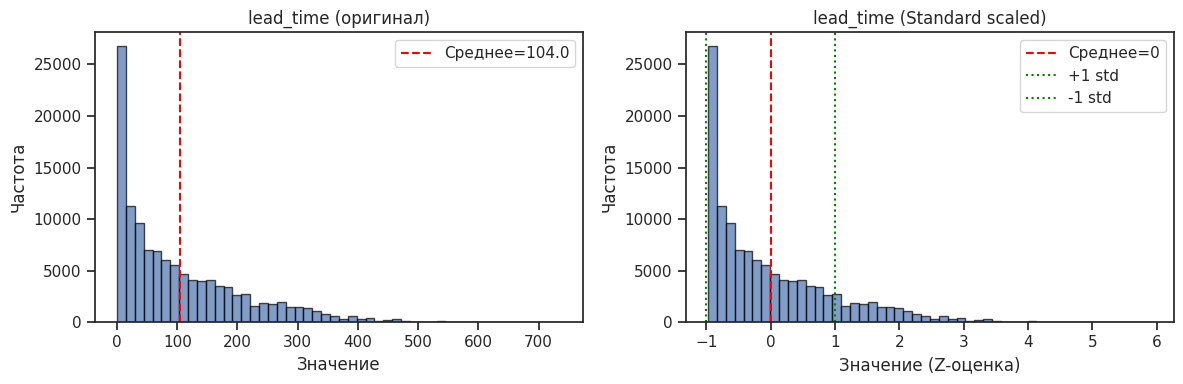

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1. Красная линия показывает среднее, зеленые - границы ±1 стандартного отклонения.

Колонка: stays_in_weekend_nights
До масштабирования - среднее: 0.93, std: 1.00
После масштабирования - среднее: 0.00, std: 1.00


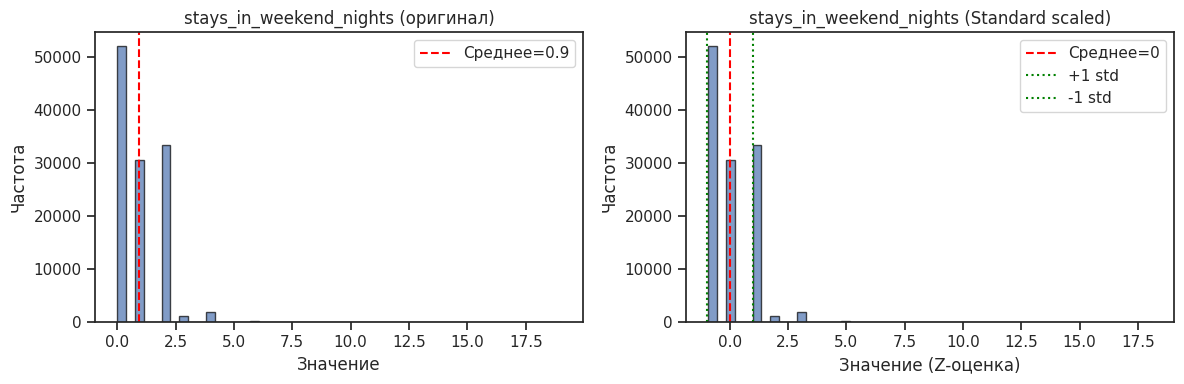

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1. Красная линия показывает среднее, зеленые - границы ±1 стандартного отклонения.

Колонка: stays_in_week_nights
До масштабирования - среднее: 2.50, std: 1.91
После масштабирования - среднее: -0.00, std: 1.00


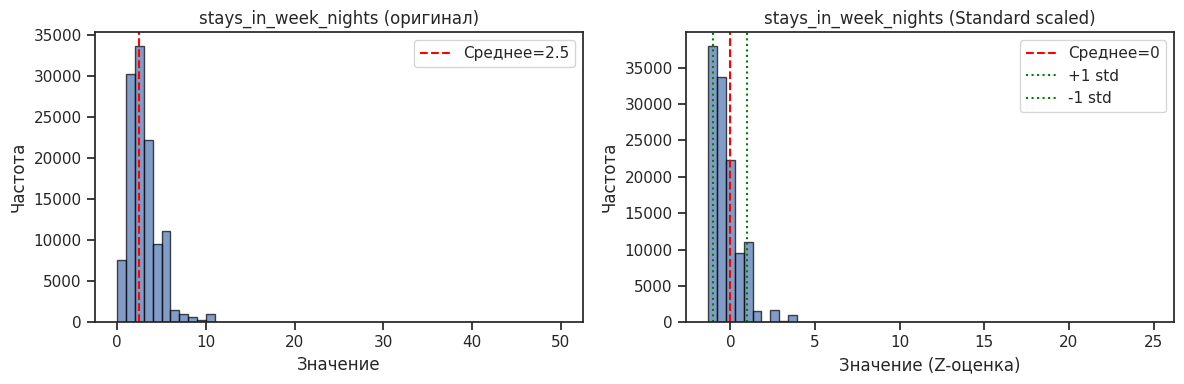

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1. Красная линия показывает среднее, зеленые - границы ±1 стандартного отклонения.

Колонка: adults
До масштабирования - среднее: 1.86, std: 0.58
После масштабирования - среднее: 0.00, std: 1.00


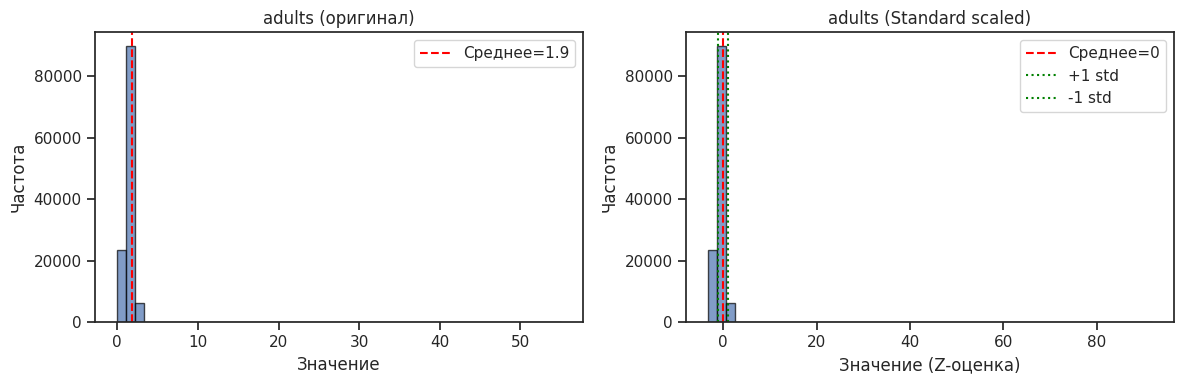

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1. Красная линия показывает среднее, зеленые - границы ±1 стандартного отклонения.

Колонка: children
До масштабирования - среднее: 0.10, std: 0.40
После масштабирования - среднее: -0.00, std: 1.00


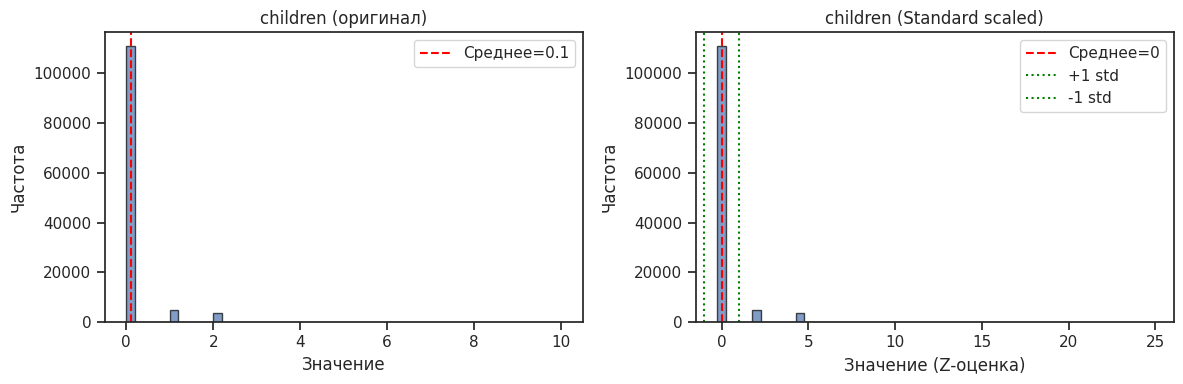

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1. Красная линия показывает среднее, зеленые - границы ±1 стандартного отклонения.

Колонка: babies
До масштабирования - среднее: 0.01, std: 0.10
После масштабирования - среднее: 0.00, std: 1.00


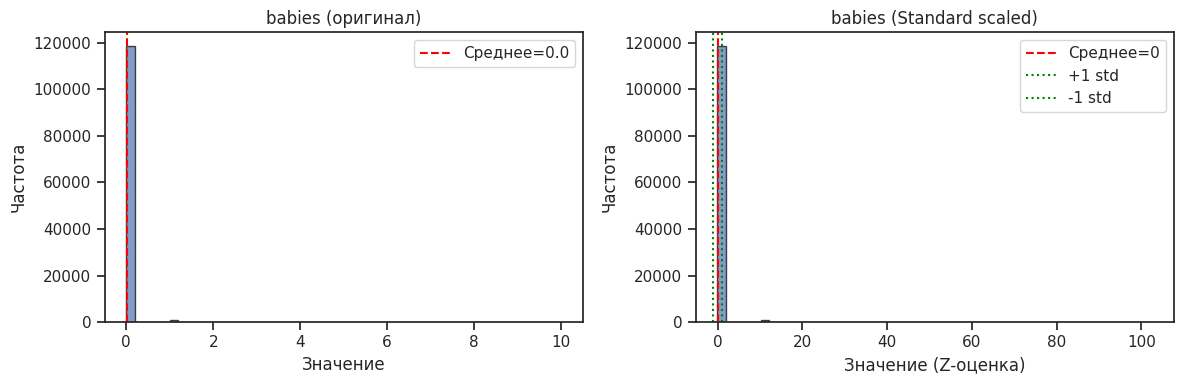

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1. Красная линия показывает среднее, зеленые - границы ±1 стандартного отклонения.

Колонка: adr
До масштабирования - среднее: 101.83, std: 50.54
После масштабирования - среднее: 0.00, std: 1.00


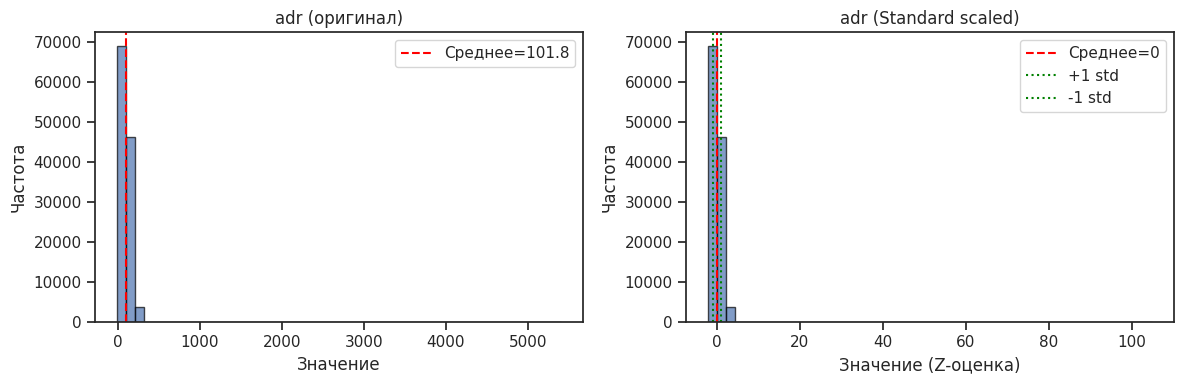

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1. Красная линия показывает среднее, зеленые - границы ±1 стандартного отклонения.


In [52]:
# @title 15. Standard масштабирование числовых признаков
from sklearn.preprocessing import StandardScaler

for col in numeric_features:
    if col in df_clean.columns:
        print(f"\nКолонка: {col}")
        print(f"До масштабирования - среднее: {df_clean[col].mean():.2f}, std: {df_clean[col].std():.2f}")

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_clean[[col]])

        print(f"После масштабирования - среднее: {scaled_data.mean():.2f}, std: {scaled_data.std():.2f}")

        df_clean[f"{col}_standard"] = scaled_data

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.hist(df_clean[col], 50, edgecolor='black', alpha=0.7)
        plt.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Среднее={df_clean[col].mean():.1f}')
        plt.title(f"{col} (оригинал)")
        plt.xlabel('Значение')
        plt.ylabel('Частота')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.hist(scaled_data, 50, edgecolor='black', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--', label='Среднее=0')
        plt.axvline(1, color='green', linestyle=':', label='+1 std')
        plt.axvline(-1, color='green', linestyle=':', label='-1 std')
        plt.title(f"{col} (Standard scaled)")
        plt.xlabel('Значение (Z-оценка)')
        plt.ylabel('Частота')
        plt.legend()
        plt.tight_layout()
        plt.show()
        print(f"Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1. Красная линия показывает среднее, зеленые - границы ±1 стандартного отклонения.")

Standard Scaling центрирует данные и приводит к единичной дисперсии.
Формула: X_new = (X - mean) / std
Графики показывают:
- Слева: оригинальные значения с отмеченным средним
- Справа: после масштабирования среднее=0, единицы измерения - стандартные отклонения
Пунктирные зеленые линии показывают границы ±1 стандартного отклонения.

In [53]:
# @title 16. Итоговый датасет
print(f"Размер исходного датасета: {df.shape}")
print(f"Размер обработанного датасета: {df_clean.shape}")
print(f"Добавлено признаков: {df_clean.shape[1] - df.shape[1]}")

print("\nПервые 5 строк итогового датасета (основные колонки):")
display_cols = ['hotel', 'lead_time', 'adults', 'children', 'country',
                'children_minmax', 'lead_time_standard']
display(df_clean[display_cols].head())

print("\nПроверка пропусков в итоговом датасете:")
nulls = df_clean.isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    print(nulls)
else:
    print("Пропусков нет")

Размер исходного датасета: (119390, 32)
Размер обработанного датасета: (119390, 77)
Добавлено признаков: 45

Первые 5 строк итогового датасета (основные колонки):


,hotel,lead_time,adults,children,country,children_minmax,lead_time_standard
0,Resort Hotel,342,2,0.0,PRT,0.0,2.227051
1,Resort Hotel,737,2,0.0,PRT,0.0,5.923385
2,Resort Hotel,7,1,0.0,GBR,0.0,-0.907814
3,Resort Hotel,13,1,0.0,GBR,0.0,-0.851667
4,Resort Hotel,14,2,0.0,GBR,0.0,-0.842309



Проверка пропусков в итоговом датасете:
Пропусков нет
